/tmp/ipython-input-3857162520.py:31: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")
/tmp/ipython-input-3857162520.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_agg = df_agg.groupby('geo').apply(flag_outliers)


[2025-12-04 17:39:51 UTC] Cleaned dataset shape: (40104, 26)


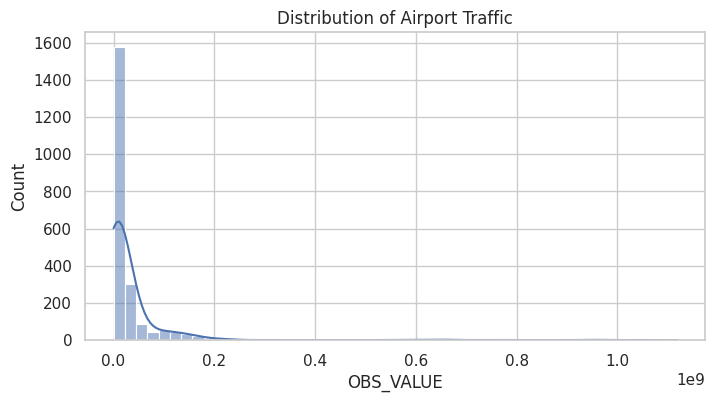

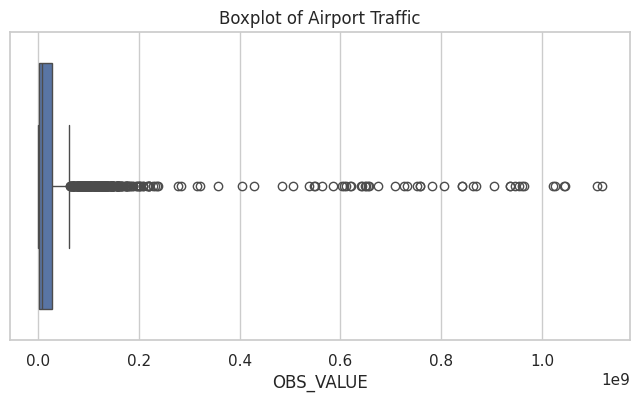

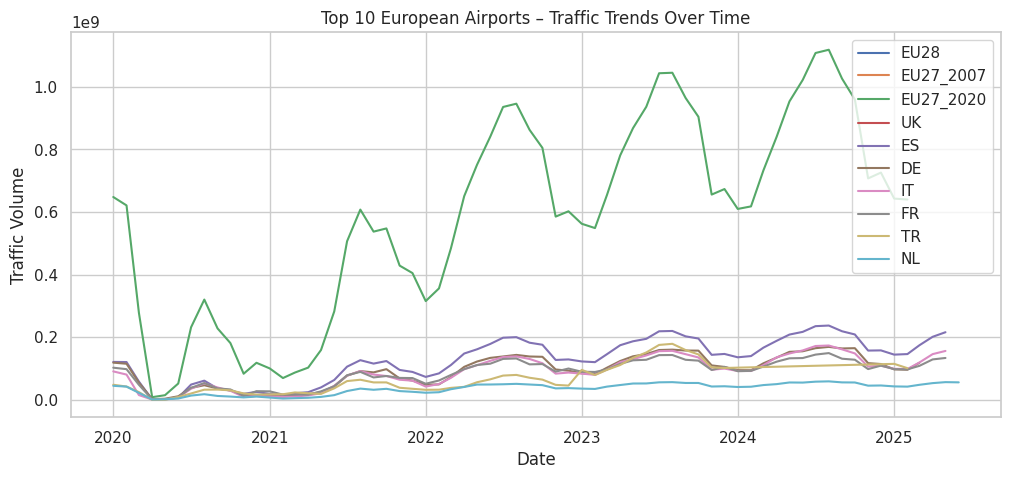


Table 2 – Summary Statistics of Selected Airports
  Airport  Count      Mean    Median       Std       Min        Max
       DE     63  93029076  97369272  50233895   2269818  169177110
       ES     65 128749480 139820232  68897389    822564  237358616
EU27_2007      1 756882394 756882394         0 756882394  756882394
EU27_2020     62 582345815 619712265 319040827   8525988 1118695838
     EU28      1 758272116 758272116         0 758272116  758272116
       FR     65  87009343  97364250  41544649   1269912  149356042
       IT     65  89165644  92155704  49877712    809940  173565804
       NL     66  36239666  42205072  17677501   1078332   59026784
       TR     50  62429706  47998434  46126183    252902  178990758
       UK      1 149100420 149100420         0 149100420  149100420
Table 3 – Top 5 Airports by Recovery Ratio
Airport Pre-COVID Mean Post-COVID Mean  Recovery Ratio
     HR      1,943,650       5,961,330            3.07
     EL     16,632,587      37,065,409          

/tmp/ipython-input-3857162520.py:31: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


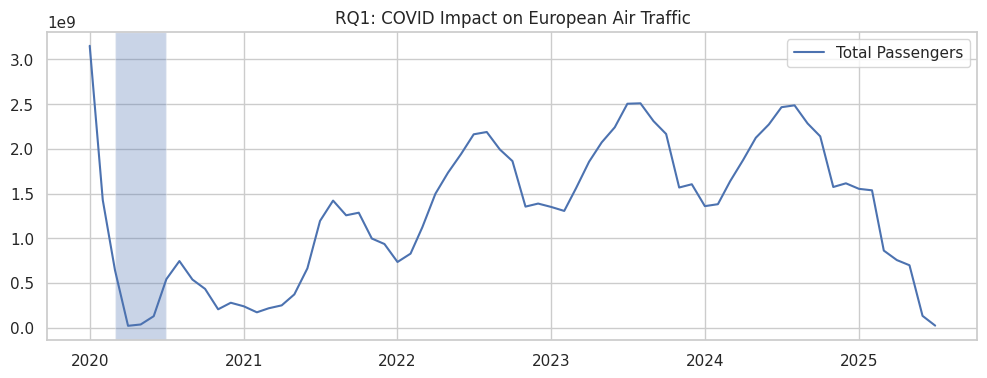

R-squared: 0.06691945062429383


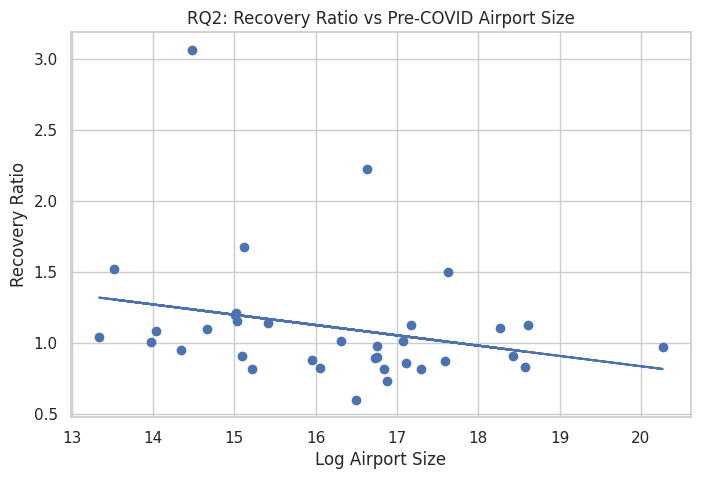

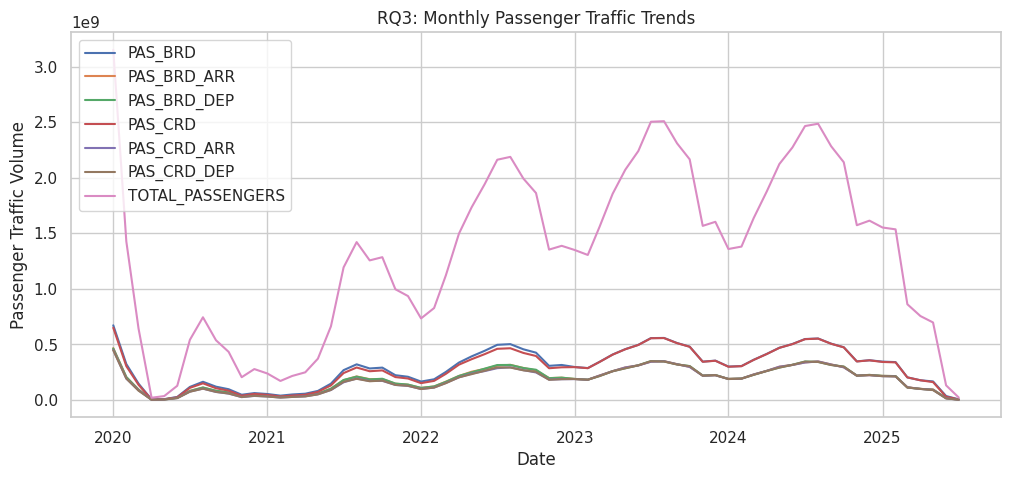

[2025-12-04 17:39:53 UTC] RQ3 Paired T-Test (Boarding vs Arrivals): t=13.59, p=0.0000


/tmp/ipython-input-3857162520.py:31: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


In [38]:
# =============================================================================
# European Airport Traffic Analysis -
# =============================================================================

import os
import sys
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

sns.set(style="whitegrid")
pd.set_option('display.max_columns', 200)
warnings.filterwarnings("ignore", category=FutureWarning)

DATAFILE = "European_Airport_Traffic.csv"
CLEAN_LOG = f"cleaning_log_{STUDENT_ID}.txt"

# ----------------------------
# Logging
# ----------------------------
def log(msg):
    ts = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")
    line = f"[{ts}] {msg}"
    print(line)
    with open(CLEAN_LOG, "a", encoding="utf-8") as f:
        f.write(line + "\n")

# ----------------------------
# Load & Clean
# ----------------------------
df = pd.read_csv(DATAFILE, low_memory=False)
df.columns = df.columns.str.strip()

df['OBS_VALUE'] = pd.to_numeric(df['OBS_VALUE'], errors='coerce')
df['date'] = pd.to_datetime(df['TIME_PERIOD'], errors='coerce')

df = df.dropna(subset=['OBS_VALUE','date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

log(f"Cleaned dataset shape: {df.shape}")

# ----------------------------
# Aggregate Airport-Month
# ----------------------------
df_agg = df.groupby(['geo','date'], as_index=False)['OBS_VALUE'].sum()

# ----------------------------
# Outlier Detection (IQR)
# ----------------------------
def flag_outliers(g):
    Q1 = g['OBS_VALUE'].quantile(0.25)
    Q3 = g['OBS_VALUE'].quantile(0.75)
    IQR = Q3 - Q1
    g['is_outlier'] = ~g['OBS_VALUE'].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    return g

df_agg = df_agg.groupby('geo').apply(flag_outliers)

# ----------------------------
# Period Features (COVID)
# ----------------------------
df_agg['period'] = np.where(df_agg['date'] < '2020-03-01','pre_covid',
                     np.where(df_agg['date'] <= '2020-06-30','covid_lockdown','post_covid'))

# ----------------------------
# EDA VISUALS (DISPLAYED)
# ----------------------------
plt.figure(figsize=(8,4))
sns.histplot(df_agg['OBS_VALUE'], bins=50, kde=True)
plt.title("Distribution of Airport Traffic")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df_agg['OBS_VALUE'])
plt.title("Boxplot of Airport Traffic")
plt.show()



# ----------------------------
# Top 10 Airports Trend
# ----------------------------

# Remove duplicate index issues
df_agg = df_agg.reset_index(drop=True)

top10 = (
    df_agg.groupby('geo', as_index=False)['OBS_VALUE']
    .mean()
    .sort_values(by='OBS_VALUE', ascending=False)
    .head(10)['geo']
)

plt.figure(figsize=(12,5))

for airport in top10:
    temp = df_agg[df_agg['geo'] == airport]
    plt.plot(temp['date'], temp['OBS_VALUE'], label=airport)

plt.legend()
plt.title("Top 10 European Airports – Traffic Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.grid(True)
plt.show()



# Select top 10 airports by mean traffic
top10_airports = df_agg.groupby('geo')['OBS_VALUE'].mean().sort_values(ascending=False).head(10).index

# Calculate summary statistics
summary_stats = df_agg[df_agg['geo'].isin(top10_airports)].groupby('geo')['OBS_VALUE'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
).reset_index()

# Fill NaNs with 0 (or any appropriate value) before converting to int
summary_stats[['Mean','Median','Std','Min','Max']] = summary_stats[['Mean','Median','Std','Min','Max']].fillna(0).round(0).astype(int)

# Rename columns for table format
summary_stats.columns = ['Airport', 'Count', 'Mean', 'Median', 'Std', 'Min', 'Max']

# Print Table 2
print("\nTable 2 – Summary Statistics of Selected Airports")
print(summary_stats.to_string(index=False))


# ----------------------------
# Top 5 Airports by Recovery Ratio
# ----------------------------

# Combine Pre-COVID, Post-COVID, and Recovery Ratio into one DataFrame
recovery_df = pd.DataFrame({
    'Airport': recovery_ratio.index,
    'Pre-COVID Mean': mean_pre.loc[recovery_ratio.index].values,
    'Post-COVID Mean': mean_post.loc[recovery_ratio.index].values,
    'Recovery Ratio': recovery_ratio.values
})

# Sort by Recovery Ratio descending and pick top 5
top5_recovery = recovery_df.sort_values(by='Recovery Ratio', ascending=False).head(5)

# Format numeric columns with commas and round Recovery Ratio
top5_recovery['Pre-COVID Mean'] = top5_recovery['Pre-COVID Mean'].map('{:,.0f}'.format)
top5_recovery['Post-COVID Mean'] = top5_recovery['Post-COVID Mean'].map('{:,.0f}'.format)
top5_recovery['Recovery Ratio'] = top5_recovery['Recovery Ratio'].round(2)

# Display the table
print("Table 3 – Top 5 Airports by Recovery Ratio")
print(top5_recovery.to_string(index=False))

# ----------------------------
# ADF Stationarity Test
# ----------------------------
monthly_total = df_agg.groupby('date')['OBS_VALUE'].sum()
adf = adfuller(monthly_total.dropna())
log(f"ADF Statistic: {adf[0]}, p-value: {adf[1]}")


# ----------------------------
# Normality Test (AUTO-SAFE)
# ----------------------------

sample_size = min(5000, len(df_agg))

k2, p = stats.normaltest(
    df_agg['OBS_VALUE']
    .dropna()
    .sample(sample_size, random_state=1)
)

log(f"Normality Test: k2={k2}, p={p}")

# ----------------------------
# RQ1: COVID IMPACT
# ----------------------------
monthly_passengers = df.groupby('date')['OBS_VALUE'].sum()

pre_mean = monthly_passengers[monthly_passengers.index<'2020-03-01'].mean()
lockdown_min = monthly_passengers[(monthly_passengers.index>'2020-03-01') & (monthly_passengers.index<'2020-06-30')].min()

plt.figure(figsize=(12,4))
plt.plot(monthly_passengers, label='Total Passengers')
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2020-06-30'), alpha=0.3)
plt.legend()
plt.title("RQ1: COVID Impact on European Air Traffic")
plt.show()

# ----------------------------
# RQ2: Recovery vs Airport Size
# ----------------------------
mean_pre = df_agg[df_agg['period']=='pre_covid'].groupby('geo')['OBS_VALUE'].mean()
mean_post = df_agg[df_agg['period']=='post_covid'].groupby('geo')['OBS_VALUE'].mean()

recovery_ratio = (mean_post / mean_pre).dropna()
airport_size = mean_pre.loc[recovery_ratio.index]

X = np.log1p(airport_size.values).reshape(-1,1)
y = recovery_ratio.values

model = LinearRegression().fit(X,y)

r_squared = model.score(X, y)
print(f"R-squared: {r_squared}")

plt.figure(figsize=(8,5))
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.title("RQ2: Recovery Ratio vs Pre-COVID Airport Size")
plt.xlabel("Log Airport Size")
plt.ylabel("Recovery Ratio")
plt.show()

# ----------------------------
# RQ3: Passenger Traffic Recovery Trends
# ----------------------------

# List of passenger traffic codes in your dataset
passenger_cols = ['PAS_BRD', 'PAS_BRD_ARR', 'PAS_BRD_DEP',
                  'PAS_CRD', 'PAS_CRD_ARR', 'PAS_CRD_DEP']

# Filter only relevant passenger columns and aggregate per month
if all(col in df.columns for col in ['date', 'OBS_VALUE', 'tra_meas']):
    df_pass = df[df['tra_meas'].isin(passenger_cols)]

    # Pivot table: index=date, columns=passenger type, values=OBS_VALUE sum
    pivot_pass = df_pass.pivot_table(index='date', columns='tra_meas',
                                    values='OBS_VALUE', aggfunc='sum')

    # Add total passenger traffic across all types
    pivot_pass['TOTAL_PASSENGERS'] = pivot_pass.sum(axis=1)

    # Plot passenger traffic trends
    plt.figure(figsize=(12,5))
    for col in pivot_pass.columns:
        plt.plot(pivot_pass.index, pivot_pass[col], label=col)
    plt.title("RQ3: Monthly Passenger Traffic Trends")
    plt.xlabel("Date")
    plt.ylabel("Passenger Traffic Volume")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Optional: Paired t-tests between types (example: boarding vs arrivals)
    tstat, pval = stats.ttest_rel(pivot_pass['PAS_BRD'].dropna(),
                                  pivot_pass['PAS_BRD_ARR'].dropna())
    log(f"RQ3 Paired T-Test (Boarding vs Arrivals): t={tstat:.2f}, p={pval:.4f}")

else:
    log("RQ3: Required columns for passenger analysis not found.")




